# Import all Necessary Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("Solarize_Light2")
%matplotlib inline

#  Import the Dataset

In [2]:
Train_data=pd.read_csv("../input/titanic/train.csv")
Test_data=pd.read_csv("../input/titanic/test.csv")
Test_y=pd.read_csv("../input/titanic/gender_submission.csv")

# Data overview

In [3]:
Train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
Train_data.shape

(891, 12)

In [5]:
Train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Exploratory Data Analysis (EDA)

In [6]:
Train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
Test_y['Survived'].value_counts()

0    266
1    152
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

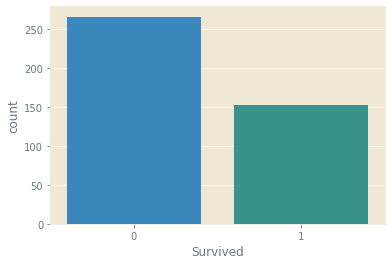

In [8]:
sns.countplot(data=Test_y, x='Survived')

<AxesSubplot:xlabel='Survived', ylabel='Age'>

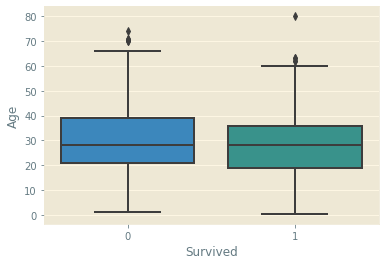

In [9]:
sns.boxplot(data=Train_data, x='Survived', y='Age')

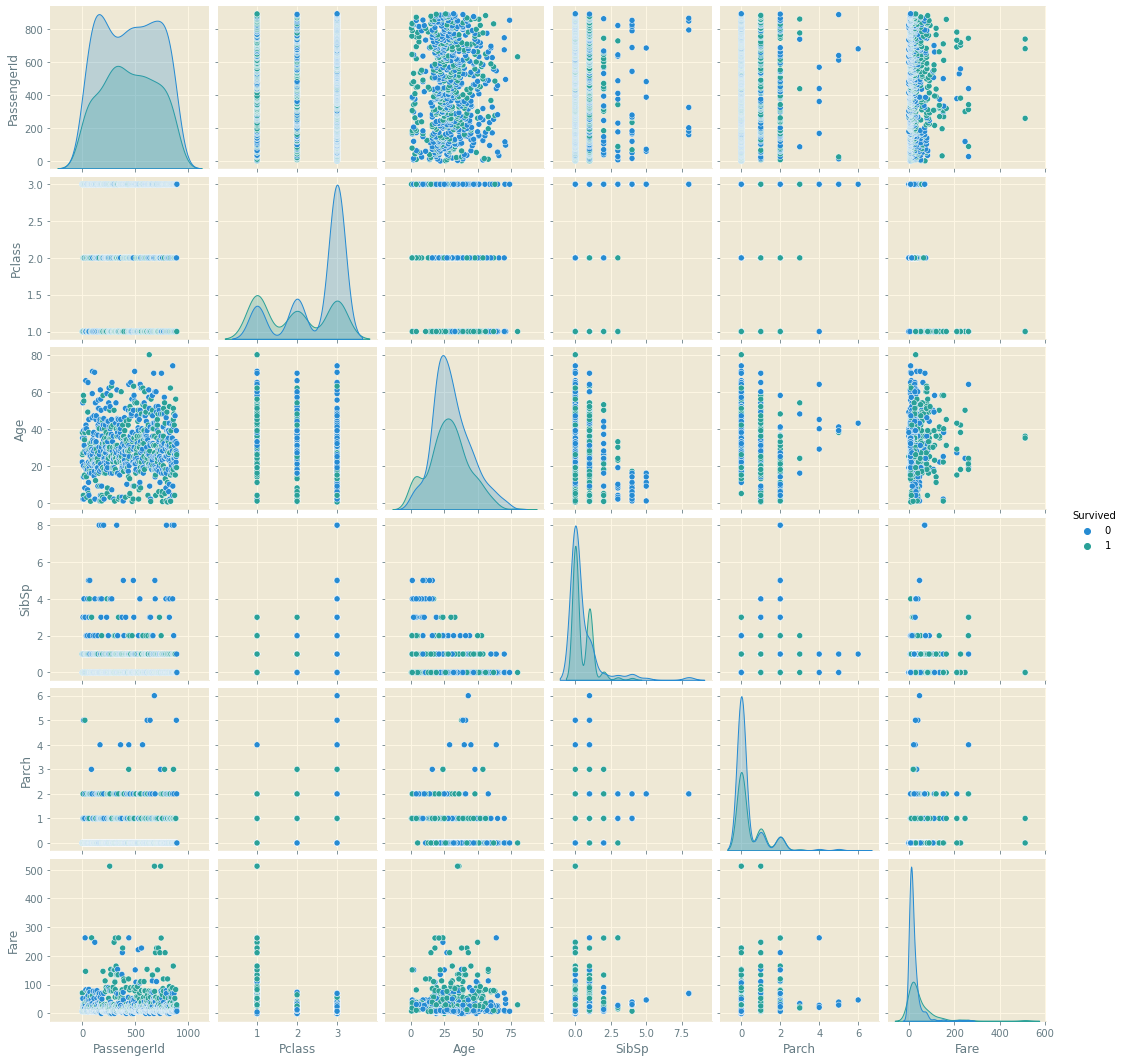

In [10]:
sns.pairplot(Train_data, hue='Survived')

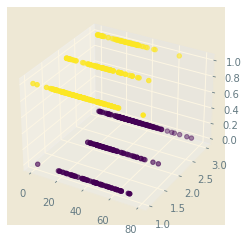

In [11]:
from mpl_toolkits.mplot3d import Axes3D
fig= plt.figure()
ax= fig.add_subplot(111, projection='3d')
ax.scatter(Train_data['Age'], Train_data['Pclass'], Train_data['Survived'], c=Train_data['Survived'])

In [12]:
((Train_data.isnull().sum())/len(Train_data))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [13]:
def missing_percent(Train_data):
    nan_percent=((Train_data.isnull().sum())/len(Train_data))*100
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [14]:
nan_percent=missing_percent(Train_data)
nan_percent

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

(array([0, 1, 2]),
 [Text(0, 0, 'Embarked'), Text(1, 0, 'Age'), Text(2, 0, 'Cabin')])

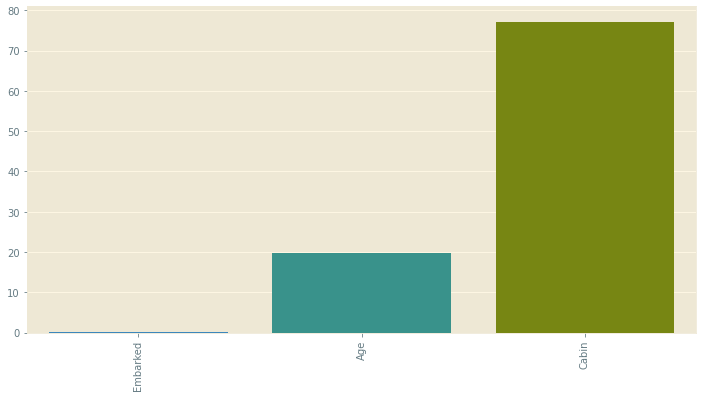

In [15]:
#plot the feature with missing indicating the percent of missing data
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [16]:
Train_data[Train_data['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [17]:
df= Train_data.dropna(axis=0, subset=['Embarked'])
df.drop("Cabin", axis = 1, inplace = True)
df["Age"].fillna(df["Age"].mean(), inplace = True)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,
/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [19]:
df.drop('PassengerId', axis=1 , inplace=True)


In [20]:
df.drop('Name' , axis=1 , inplace=True)

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


In [22]:
df.corr()['Survived'].sort_values()

Pclass     -0.335549
Age        -0.074513
SibSp      -0.034040
Parch       0.083151
Fare        0.255290
Survived    1.000000
Name: Survived, dtype: float64

# Determine the Features & Target Variable

In [23]:
df['Sex']=df['Sex'].replace({'male':0,'female':1})
df.drop([ 'Ticket', 'Fare','Embarked'], axis = 1, inplace = True)
X= df.drop('Survived', axis=1)
y= df['Survived']

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    int64  
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 48.6 KB


# Split the Dataset to Tain & Test set

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

# Scaling the Features

In [26]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [27]:
scaler.fit(X_train)

StandardScaler()

In [28]:
scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)

# Train the Model

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
log_model= LogisticRegression()

In [31]:
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

In [32]:
#Model Coeficient:
log_model.coef_

array([[-0.94484205,  1.27308344, -0.50282286, -0.34606649, -0.08770298]])

# Predicting Test Data

In [33]:
y_pred= log_model.predict(scaled_X_test)

# Evaluating the Model

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

In [35]:
accuracy_score(y_test, y_pred)

0.8426966292134831

In [36]:
confusion_matrix(y_test, y_pred)

array([[52,  5],
       [ 9, 23]])

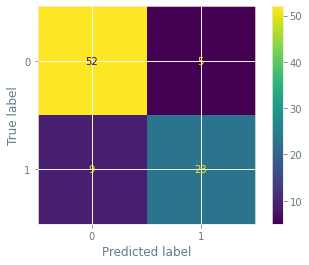

In [37]:
plot_confusion_matrix(log_model, scaled_X_test, y_test)

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        57
           1       0.82      0.72      0.77        32

    accuracy                           0.84        89
   macro avg       0.84      0.82      0.82        89
weighted avg       0.84      0.84      0.84        89



# Evaluating Curves and AUC

In [39]:
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve

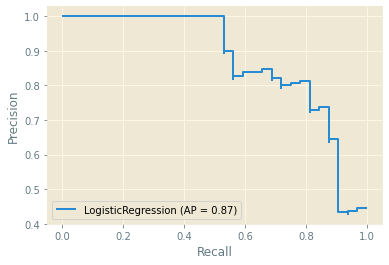

In [40]:
plot_precision_recall_curve(log_model, scaled_X_test, y_test)

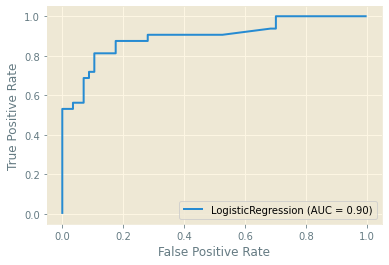

In [41]:
plot_roc_curve(log_model, scaled_X_test, y_test)